<div class="usecase-title">YOLO11 Crack Classification and Still-Image Testing</div>

<div class="usecase-authors"><b>Authored by: </b>Kavita</div>

<div class="usecase-duration"><b>Duration:</b> 75 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, PyTorch, Ultralytics YOLO, image classification</div>
</div>

<div class="usecase-section-header">Scenario</div>

A practitioner needs a lightweight binary crack classifier for SDNET2018 that can be trained from the dataset mount provided by API v2.1 and then reused for held-out evaluation and still-image inference. They want a clear, repeatable workflow that prepares the data, fine-tunes YOLO11, and saves predictions they can inspect later.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will:
- prepare SDNET2018 for binary crack classification using a reproducible manifest
- fine-tune YOLO11 classification on the API v2.1 dataset mount
- evaluate the trained model and generate still-image predictions with confidence scores
- document how pretrained weights are fetched from the official Ultralytics assets release

<div class="usecase-section-header">Background</div>

SDNET2018 contains surface images that are well suited to binary crack classification. In this notebook, the dataset is accessed through the API v2.1 mount, converted into a YOLO classification layout, and trained with Ultralytics YOLO11. The notebook also keeps the runtime outputs useful by saving evaluation results and still-image predictions for later inspection.

<div class="usecase-section-header">References</div>

- SDNET2018 crack dataset, accessed through the API v2.1 dataset mount used by this workspace
- Ultralytics YOLO documentation and pretrained weights: https://github.com/ultralytics/assets/releases/tag/v8.4.0
- Ultralytics documentation: https://docs.ultralytics.com/

In [1]:
from __future__ import annotations

import importlib.util
import os
import random
import shutil
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", message="Error fetching version info")

ULTRALYTICS_AVAILABLE = importlib.util.find_spec("ultralytics") is not None
if ULTRALYTICS_AVAILABLE:
    from ultralytics import YOLO
else:
    YOLO = None
    print("Ultralytics is not installed in this kernel. Install it, then rerun the training and inference cells.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_ROOT = Path(os.environ.get("API_V21_DATASET_ROOT", "dataset"))
ARTIFACTS_ROOT = Path("artifacts")
MANIFEST_DIR = ARTIFACTS_ROOT / "manifests"
PLOT_DIR = ARTIFACTS_ROOT / "plots"
YOLO_DATA_ROOT = ARTIFACTS_ROOT / "yolo11_sdnet2018_binary_cls_data"
RUNS_DIR = ARTIFACTS_ROOT / "yolo11_runs"
PREDICTION_DIR = ARTIFACTS_ROOT / "yolo11_predictions"

for folder in [MANIFEST_DIR, PLOT_DIR, YOLO_DATA_ROOT, RUNS_DIR, PREDICTION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SURFACE_NAMES = {"D": "Deck", "P": "Pavement", "W": "Wall"}
SUBCLASS_NAMES = {
    "CD": "Cracked",
    "UD": "Uncracked",
    "CP": "Cracked",
    "UP": "Uncracked",
    "CW": "Cracked",
    "UW": "Uncracked",
}
CLASS_FOLDER_NAMES = {"Cracked": "cracked", "Uncracked": "uncracked"}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Expected the SDNET2018 dataset under {DATASET_ROOT.resolve()}, but the folder was not found. Provide it via the API v2.1 mount path before running this notebook."
    )

MODEL_WEIGHTS = "yolo11n-cls.pt"
RUN_NAME = "yolo11n_sdnet2018_binary_cls"
IMAGE_SIZE = 224
EPOCHS = 20
BATCH_SIZE = 64
PATIENCE = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"
WORKERS = 2
REBUILD_YOLO_DATASET = False

CUSTOM_STILL_IMAGE_DIR = None
DEMO_IMAGE_COUNT = 12
CONFUSION_MATRIX_SAMPLE_SIZE = 512


## Build A Binary Manifest From SDNET2018

The local folder structure is converted into a dataframe with the original file path, surface metadata, the crack label, and the YOLO classification class folder name.


In [2]:
def collect_sdnet2018_manifest(root: Path) -> pd.DataFrame:
    records = []

    for surface_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        surface_code = surface_dir.name
        surface_name = SURFACE_NAMES.get(surface_code, surface_code)

        for subclass_dir in sorted(path for path in surface_dir.iterdir() if path.is_dir()):
            subclass_code = subclass_dir.name
            crack_status = SUBCLASS_NAMES.get(subclass_code, "Unknown")
            class_name = CLASS_FOLDER_NAMES.get(crack_status)

            if class_name is None:
                continue

            for image_path in sorted(subclass_dir.glob("*.jpg")):
                records.append(
                    {
                        "path": image_path.resolve(),
                        "relative_path": image_path.as_posix(),
                        "surface_code": surface_code,
                        "surface_name": surface_name,
                        "subclass_code": subclass_code,
                        "surface_class": f"{surface_code}/{subclass_code}",
                        "crack_status": crack_status,
                        "class_name": class_name,
                        "binary_label": int(class_name == "cracked"),
                    }
                )

    manifest = pd.DataFrame(records)
    if manifest.empty:
        raise RuntimeError("No JPG files were found under the dataset directory.")
    return manifest


manifest_df = collect_sdnet2018_manifest(DATASET_ROOT)
display(manifest_df.head())
print(f"Collected {len(manifest_df):,} SDNET2018 image records")


,path,relative_path,surface_code,surface_name,subclass_code,surface_class,crack_status,class_name,binary_label
0,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-115.jpg,D,Deck,CD,D/CD,Cracked,cracked,1
1,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-139.jpg,D,Deck,CD,D/CD,Cracked,cracked,1
2,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-151.jpg,D,Deck,CD,D/CD,Cracked,cracked,1
3,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-157.jpg,D,Deck,CD,D/CD,Cracked,cracked,1
4,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-169.jpg,D,Deck,CD,D/CD,Cracked,cracked,1


Collected 56,092 SDNET2018 image records


## Dataset Summary

Before training, we verify the binary class balance and the contribution from each surface type.


,class_name,count
0,uncracked,47608
1,cracked,8484


,surface_name,crack_status,count
0,Deck,Cracked,2025
1,Deck,Uncracked,11595
2,Pavement,Cracked,2608
3,Pavement,Uncracked,21726
4,Wall,Cracked,3851
5,Wall,Uncracked,14287


Saved summary plot to artifacts\plots\yolo11_sdnet2018_binary_distribution.png


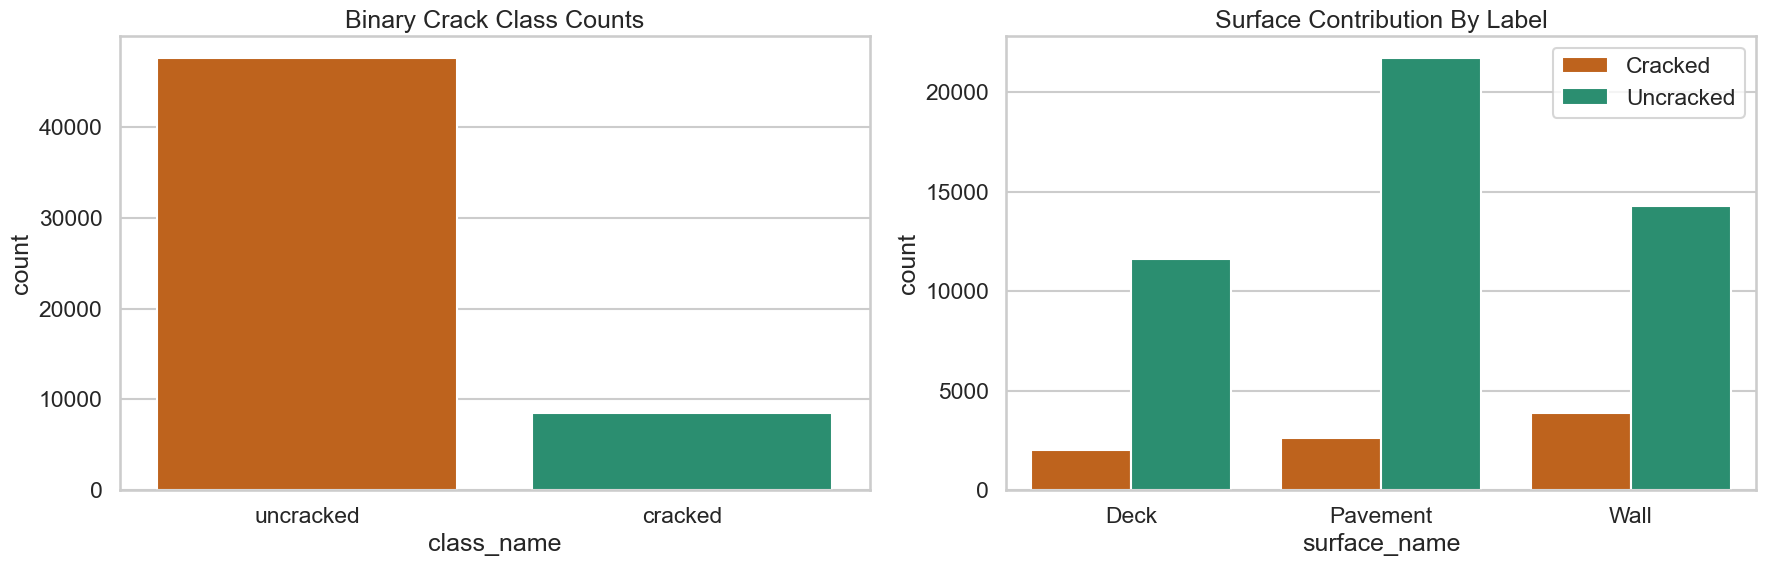

In [3]:
summary_df = (
    manifest_df.groupby(["surface_name", "crack_status"])
    .size()
    .reset_index(name="count")
)

binary_counts_df = (
    manifest_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)

display(binary_counts_df)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=binary_counts_df,
    x="class_name",
    y="count",
    hue="class_name",
    ax=axes[0],
    palette=["#d95f02", "#1b9e77"],
    legend=False,
)
axes[0].set_title("Binary Crack Class Counts")

sns.barplot(
    data=summary_df,
    x="surface_name",
    y="count",
    hue="crack_status",
    palette={"Cracked": "#d95f02", "Uncracked": "#1b9e77"},
    ax=axes[1],
)
axes[1].set_title("Surface Contribution By Label")
axes[1].legend(title="")

plt.tight_layout()

summary_plot_path = PLOT_DIR / "yolo11_sdnet2018_binary_distribution.png"
fig.savefig(summary_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved summary plot to {summary_plot_path}")


## Create Stratified Train, Validation, And Test Splits

We stratify by the original six SDNET2018 subclasses so the final binary classifier still sees a balanced mix of deck, pavement, and wall examples in every split.


In [4]:
def stratified_train_val_test_split(
    df: pd.DataFrame,
    stratify_col: str = "surface_class",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train_size + val_size + test_size must sum to 1.0")

    train_df, temp_df = train_test_split(
        df,
        train_size=train_size,
        stratify=df[stratify_col],
        random_state=seed,
    )

    relative_test_size = test_size / (val_size + test_size)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        stratify=temp_df[stratify_col],
        random_state=seed,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = stratified_train_val_test_split(manifest_df)

split_manifest_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

split_summary_df = (
    split_manifest_df.groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(split_summary_df)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


class_name,split,cracked,uncracked
0,test,1272,7142
1,train,5939,33325
2,val,1273,7141


Train: 39,264 | Val: 8,414 | Test: 8,414


## Prepare Ultralytics Classification Directory Layout

Ultralytics classification expects:

- `root/train/class_name/*.jpg`
- `root/val/class_name/*.jpg`
- `root/test/class_name/*.jpg`

To avoid unnecessary duplication, this notebook first attempts to create hard links and falls back to copying if hard linking is not available.


In [5]:
def safe_flat_name(relative_path: str) -> str:
    return relative_path.replace("/", "__").replace("\\", "__")


def link_or_copy_file(source: Path, destination: Path) -> str:
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists():
        return "exists"

    try:
        os.link(source, destination)
        return "hardlink"
    except OSError:
        shutil.copy2(source, destination)
        return "copy"


def prepare_yolo_classification_dataset(
    split_df: pd.DataFrame,
    output_root: Path,
    rebuild: bool = False,
) -> pd.DataFrame:
    if rebuild and output_root.exists():
        shutil.rmtree(output_root)

    output_root.mkdir(parents=True, exist_ok=True)
    records = []

    for row in split_df.itertuples(index=False):
        source_path = Path(row.path)
        destination_path = output_root / row.split / row.class_name / safe_flat_name(row.relative_path)
        mode = link_or_copy_file(source_path, destination_path)

        records.append(
            {
                "split": row.split,
                "class_name": row.class_name,
                "source_path": str(source_path),
                "destination_path": destination_path.as_posix(),
                "link_mode": mode,
            }
        )

    return pd.DataFrame(records)


yolo_layout_df = prepare_yolo_classification_dataset(
    split_manifest_df,
    YOLO_DATA_ROOT,
    rebuild=REBUILD_YOLO_DATASET,
)

yolo_layout_summary_df = (
    yolo_layout_df.groupby(["split", "class_name", "link_mode"])
    .size()
    .reset_index(name="count")
)

display(yolo_layout_summary_df)

manifest_export_path = MANIFEST_DIR / "yolo11_sdnet2018_binary_split_manifest.csv"
split_manifest_df.to_csv(manifest_export_path, index=False)
print(f"Saved split manifest to {manifest_export_path}")
print(f"YOLO classification dataset root: {YOLO_DATA_ROOT.resolve()}")


,split,class_name,link_mode,count
0,test,cracked,exists,1272
1,test,uncracked,exists,7142
2,train,cracked,exists,5939
3,train,uncracked,exists,33325
4,val,cracked,exists,1273
5,val,uncracked,exists,7141


Saved split manifest to artifacts\manifests\yolo11_sdnet2018_binary_split_manifest.csv
YOLO classification dataset root: C:\Users\sumit\Desktop\kavita_capstone\project_6a\artifacts\yolo11_sdnet2018_binary_cls_data


## Sample Training Images

This quick grid helps confirm that the directory conversion did not corrupt or mislabel the images.


Saved training sample plot to artifacts\plots\yolo11_sdnet2018_training_samples.png


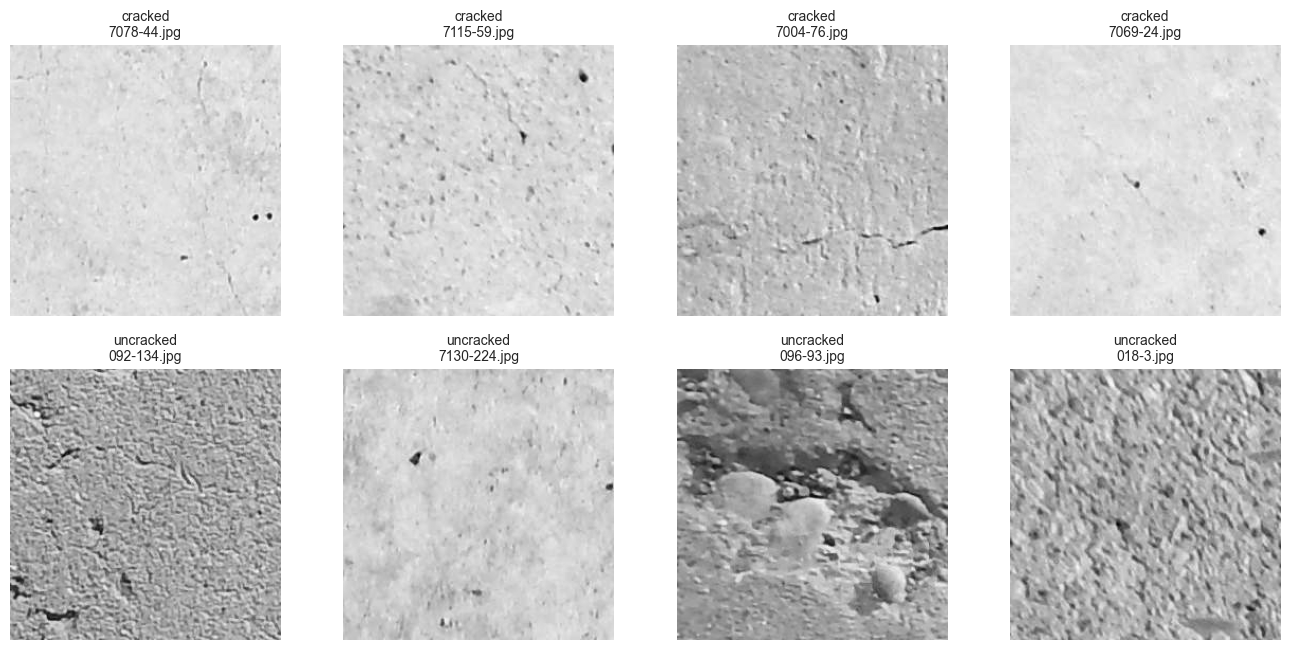

In [6]:
def load_grayscale(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    return image


def show_training_samples(df: pd.DataFrame, rows_per_class: int = 4, seed: int = SEED) -> None:
    sampled_frames = []
    for class_name in sorted(df["class_name"].unique()):
        sampled_frames.append(
            df[df["class_name"] == class_name]
            .sample(n=rows_per_class, random_state=seed)
            .assign(display_class=class_name)
        )

    sample_df = pd.concat(sampled_frames, ignore_index=True)
    fig, axes = plt.subplots(2, rows_per_class, figsize=(3.4 * rows_per_class, 6.8))

    for row_index, class_name in enumerate(sorted(sample_df["display_class"].unique())):
        class_rows = sample_df[sample_df["display_class"] == class_name].reset_index(drop=True)
        for column_index, row in class_rows.iterrows():
            ax = axes[row_index, column_index]
            image = load_grayscale(Path(row["path"]))
            ax.imshow(image, cmap="gray")
            ax.set_title(f"{class_name}\n{Path(row['relative_path']).name}", fontsize=10)
            ax.axis("off")

    plt.tight_layout()
    sample_plot_path = PLOT_DIR / "yolo11_sdnet2018_training_samples.png"
    fig.savefig(sample_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved training sample plot to {sample_plot_path}")


show_training_samples(train_df, rows_per_class=4)


## Load YOLO11 Classification Model

Ultralytics downloads pretrained weights automatically on first use. That step requires internet access the first time you run the training cell with `yolo11n-cls.pt`.


In [7]:
yolo_model = None

if ULTRALYTICS_AVAILABLE:
    print(f"Ultralytics is available. Training device will be: {DEVICE}")
    print(f"Configured backbone: {MODEL_WEIGHTS}")
else:
    print("Skipping model initialization because Ultralytics is not installed in this kernel.")


Ultralytics is available. Training device will be: 0
Configured backbone: yolo11n-cls.pt


## Train YOLO11 On The Binary Crack Dataset

The training cell uses conservative augmentation settings for grayscale infrastructure imagery:

- horizontal flips enabled
- small vertical flip probability
- no hue or saturation shifts
- light brightness variation only


In [8]:
train_results = None
trained_weights_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"

if not ULTRALYTICS_AVAILABLE:
    print("Training skipped because Ultralytics is not installed.")
else:
    yolo_model = YOLO(MODEL_WEIGHTS)
    train_results = yolo_model.train(
        data=str(YOLO_DATA_ROOT),
        epochs=EPOCHS,
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        project=str(RUNS_DIR),
        name=RUN_NAME,
        exist_ok=True,
        seed=SEED,
        device=DEVICE,
        workers=WORKERS,
        patience=PATIENCE,
        fliplr=0.5,
        flipud=0.15,
        erasing=0.10,
        hsv_h=0.0,
        hsv_s=0.0,
        hsv_v=0.08,
        verbose=True,
        plots=True,
    )

    print(f"Expected trained weights path: {trained_weights_path}")


New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.13.11 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=artifacts\yolo11_sdnet2018_binary_cls_data, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.15, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.08, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0,

## Evaluate On The Held-Out Test Split

This section uses both the built-in Ultralytics validation flow and a confusion-matrix check on still images.


In [9]:
test_metrics = None

if not ULTRALYTICS_AVAILABLE:
    print("Validation skipped because Ultralytics is not installed.")
elif not trained_weights_path.exists():
    print(f"Validation skipped because trained weights were not found at {trained_weights_path}")
else:
    trained_model = YOLO(str(trained_weights_path))

    try:
        test_metrics = trained_model.val(
            data=str(YOLO_DATA_ROOT),
            split="test",
            imgsz=IMAGE_SIZE,
            batch=BATCH_SIZE,
            device=DEVICE,
        )
    except TypeError:
        print("This Ultralytics version did not accept split='test'. Falling back to the default validation split.")
        test_metrics = trained_model.val(
            data=str(YOLO_DATA_ROOT),
            imgsz=IMAGE_SIZE,
            batch=BATCH_SIZE,
            device=DEVICE,
        )

    metric_rows = []
    for metric_name in ["top1", "top5", "fitness"]:
        metric_value = getattr(test_metrics, metric_name, None)
        if metric_value is not None:
            metric_rows.append({"metric": metric_name, "value": float(metric_value)})

    if metric_rows:
        display(pd.DataFrame(metric_rows))


Validation skipped because trained weights were not found at artifacts\yolo11_runs\yolo11n_sdnet2018_binary_cls\weights\best.pt


## Helper Functions For Still-Image Inference

The functions below let you predict on a folder of custom still images or sample held-out test images from SDNET2018, save a predictions table, and visualize results with confidence scores.


In [10]:
def to_float(value) -> float:
    if hasattr(value, "item"):
        return float(value.item())
    return float(value)


def select_still_images(
    test_manifest: pd.DataFrame,
    custom_dir: str | None = None,
    n_images: int = DEMO_IMAGE_COUNT,
    seed: int = SEED,
) -> pd.DataFrame:
    if custom_dir:
        custom_path = Path(custom_dir)
        if custom_path.exists():
            image_paths = []
            for pattern in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
                image_paths.extend(sorted(custom_path.glob(pattern)))

            if image_paths:
                return pd.DataFrame(
                    {
                        "path": [str(p.resolve()) for p in image_paths[:n_images]],
                        "relative_path": [p.name for p in image_paths[:n_images]],
                        "class_name": [None] * min(n_images, len(image_paths)),
                        "source": ["custom"] * min(n_images, len(image_paths)),
                    }
                )

    sampled_df = (
        test_manifest.sample(n=min(n_images, len(test_manifest)), random_state=seed)
        .copy()
        .reset_index(drop=True)
    )
    sampled_df["path"] = sampled_df["path"].astype(str)
    sampled_df["source"] = "held_out_test"
    return sampled_df


def predict_image_paths(model, image_paths: list[Path], batch_size: int = 32) -> pd.DataFrame:
    results = model.predict(
        source=[str(path) for path in image_paths],
        batch=batch_size,
        verbose=False,
    )

    rows = []
    for result in results:
        predicted_index = int(result.probs.top1)
        predicted_confidence = to_float(result.probs.top1conf)
        rows.append(
            {
                "path": str(Path(result.path).resolve()),
                "predicted_index": predicted_index,
                "predicted_class": result.names[predicted_index],
                "confidence": predicted_confidence,
            }
        )

    return pd.DataFrame(rows)


def visualize_predictions(prediction_df: pd.DataFrame, rows: int = 3, cols: int = 4) -> None:
    total = min(len(prediction_df), rows * cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.3 * cols, 3.8 * rows))
    axes = np.atleast_2d(axes)

    for ax in axes.flatten():
        ax.axis("off")

    for ax, row in zip(axes.flatten(), prediction_df.head(total).itertuples(index=False)):
        image = load_grayscale(Path(row.path))
        true_label = getattr(row, "class_name", None)
        true_text = f"true: {true_label}" if pd.notna(true_label) else "true: unknown"
        ax.imshow(image, cmap="gray")
        ax.set_title(
            f"pred: {row.predicted_class} ({row.confidence:.2f})\n{true_text}",
            fontsize=10,
        )
        ax.axis("off")

    plt.tight_layout()


## Test YOLO11 On Still Images

By default, this cell samples held-out still images from the test split. If `CUSTOM_STILL_IMAGE_DIR` points to another folder, the notebook will use those images instead.


In [11]:
still_predictions_df = None

if not ULTRALYTICS_AVAILABLE:
    print("Still-image testing skipped because Ultralytics is not installed.")
elif not trained_weights_path.exists():
    print(f"Still-image testing skipped because trained weights were not found at {trained_weights_path}")
else:
    trained_model = YOLO(str(trained_weights_path))
    still_image_df = select_still_images(
        test_df,
        custom_dir=CUSTOM_STILL_IMAGE_DIR,
        n_images=DEMO_IMAGE_COUNT,
    )

    still_predictions_df = predict_image_paths(
        trained_model,
        [Path(path) for path in still_image_df["path"].tolist()],
        batch_size=min(16, DEMO_IMAGE_COUNT),
    ).merge(
        still_image_df[["path", "relative_path", "class_name", "source"]],
        on="path",
        how="left",
    )

    prediction_export_path = PREDICTION_DIR / "yolo11_sdnet2018_still_image_predictions.csv"
    still_predictions_df.to_csv(prediction_export_path, index=False)
    display(still_predictions_df)
    print(f"Saved still-image predictions to {prediction_export_path}")

    visualize_predictions(still_predictions_df, rows=3, cols=4)

    still_plot_path = PLOT_DIR / "yolo11_sdnet2018_still_image_predictions.png"
    plt.savefig(still_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved still-image prediction grid to {still_plot_path}")


Still-image testing skipped because trained weights were not found at artifacts\yolo11_runs\yolo11n_sdnet2018_binary_cls\weights\best.pt


## Confusion Matrix On A Test Subset

This is a lightweight smoke test on held-out still images. Increase `CONFUSION_MATRIX_SAMPLE_SIZE` or set it to `None` if you want to score the entire test split.


In [12]:
confusion_df = None

if not ULTRALYTICS_AVAILABLE:
    print("Confusion-matrix evaluation skipped because Ultralytics is not installed.")
elif not trained_weights_path.exists():
    print(f"Confusion-matrix evaluation skipped because trained weights were not found at {trained_weights_path}")
else:
    trained_model = YOLO(str(trained_weights_path))
    if CONFUSION_MATRIX_SAMPLE_SIZE is None:
        eval_df = test_df.copy()
    else:
        eval_df = test_df.sample(
            n=min(CONFUSION_MATRIX_SAMPLE_SIZE, len(test_df)),
            random_state=SEED,
        ).copy()

    eval_df["path"] = eval_df["path"].astype(str)

    confusion_df = predict_image_paths(
        trained_model,
        [Path(path) for path in eval_df["path"].tolist()],
        batch_size=32,
    ).merge(
        eval_df[["path", "class_name"]],
        on="path",
        how="left",
    )

    labels = ["cracked", "uncracked"]
    cm = confusion_matrix(
        confusion_df["class_name"],
        confusion_df["predicted_class"],
        labels=labels,
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{label}" for label in labels],
        columns=[f"pred_{label}" for label in labels],
    )
    display(cm_df)

    report = classification_report(
        confusion_df["class_name"],
        confusion_df["predicted_class"],
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    display(pd.DataFrame(report).transpose().round(4))

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title("YOLO11 still-image confusion matrix")
    plt.tight_layout()

    confusion_plot_path = PLOT_DIR / "yolo11_sdnet2018_confusion_matrix.png"
    fig.savefig(confusion_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved confusion matrix to {confusion_plot_path}")


Confusion-matrix evaluation skipped because trained weights were not found at artifacts\yolo11_runs\yolo11n_sdnet2018_binary_cls\weights\best.pt
